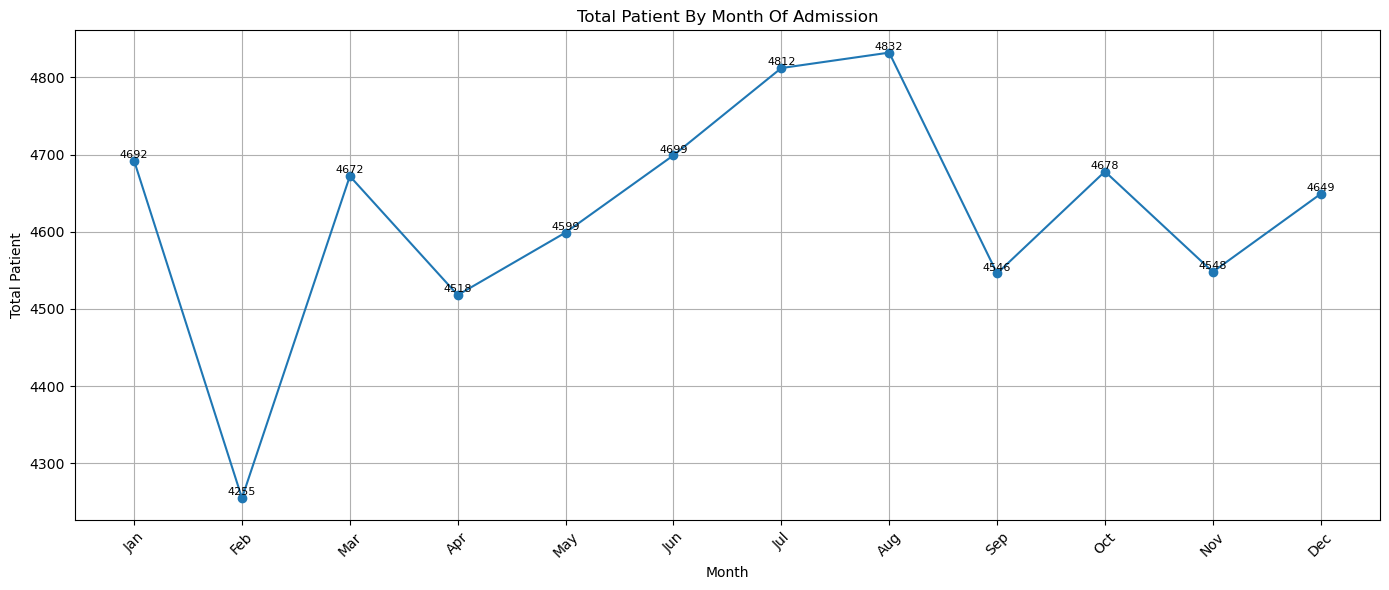

In [9]:
import pandas as pd
import statistics
import numpy as np
import matplotlib.pyplot as plt
import squarify

# Declaration
# Exploratory Data Analysis (EDA) - Line Chart Total Patient By Month Of Admission
data = pd.read_csv("modified_healthcare_dataset.csv")

# Get Month
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], errors='coerce')
data['Month'] = data['Date of Admission'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data['MonthName'] = data['Month'].apply(lambda x: month_names[x - 1])

total_patients = data['MonthName'].value_counts().reindex(month_names, fill_value=0)

# Plot Line Chart
plt.figure(figsize=(14, 6))
plt.plot(total_patients.index, total_patients.values, marker='o')
plt.title('Total Patient By Month Of Admission')
plt.xlabel('Month')
plt.ylabel('Total Patient')
plt.xticks(rotation=45)
plt.grid(True)
# Add Labels
for x, y in zip(total_patients.index, total_patients.values):
    plt.text(x, y + 1, str(int(y)), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

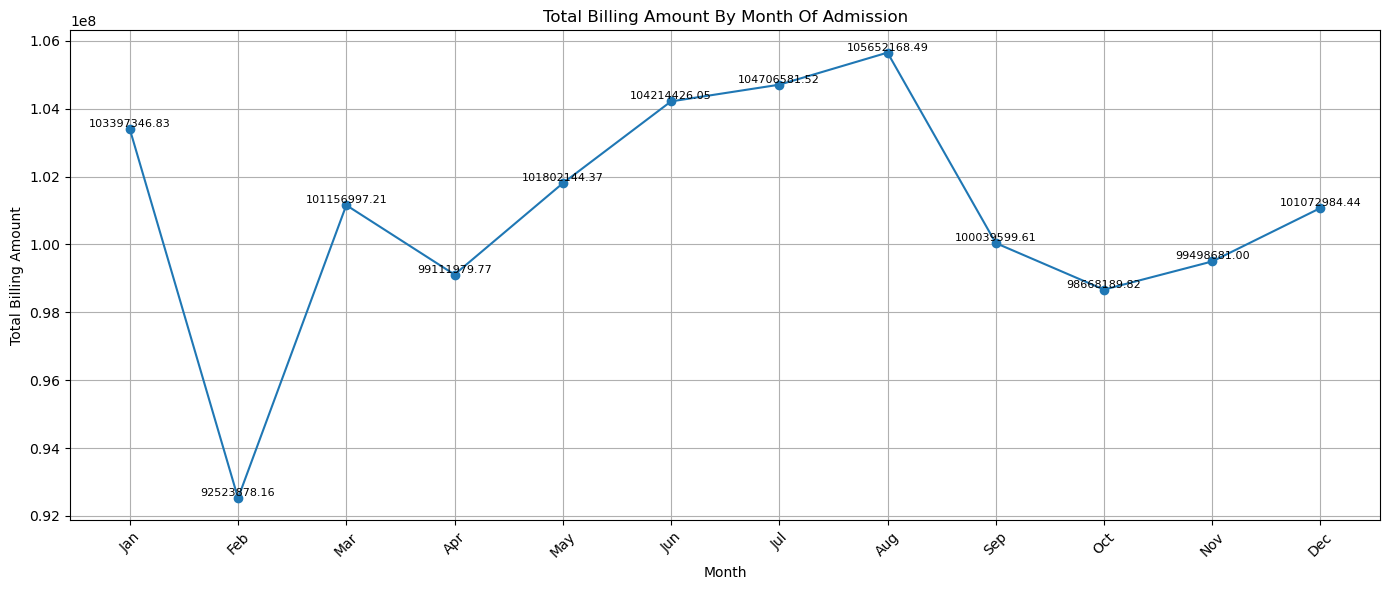

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Declaration
# Exploratory Data Analysis (EDA) - Line Chart Total Billing Amount By Month Of Admission
data = pd.read_csv("modified_healthcare_dataset.csv")

# Get Month
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], errors='coerce')
data['Month'] = data['Date of Admission'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data['MonthName'] = data['Month'].apply(lambda x: month_names[x - 1])

# Group by Month and sum Billing Amount
data['Billing Amount'] = pd.to_numeric(data['Billing Amount'], errors='coerce')
monthly_billing = data.groupby('MonthName')['Billing Amount'].sum().reindex(month_names, fill_value=0)

# Plot line chart
plt.figure(figsize=(14, 6))
plt.plot(monthly_billing.index, monthly_billing.values, marker='o')
plt.title('Total Billing Amount By Month Of Admission')
plt.xlabel('Month')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45)
plt.grid(True)
for x, y in zip(monthly_billing.index, monthly_billing.values):
    plt.text(x, y + 1, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

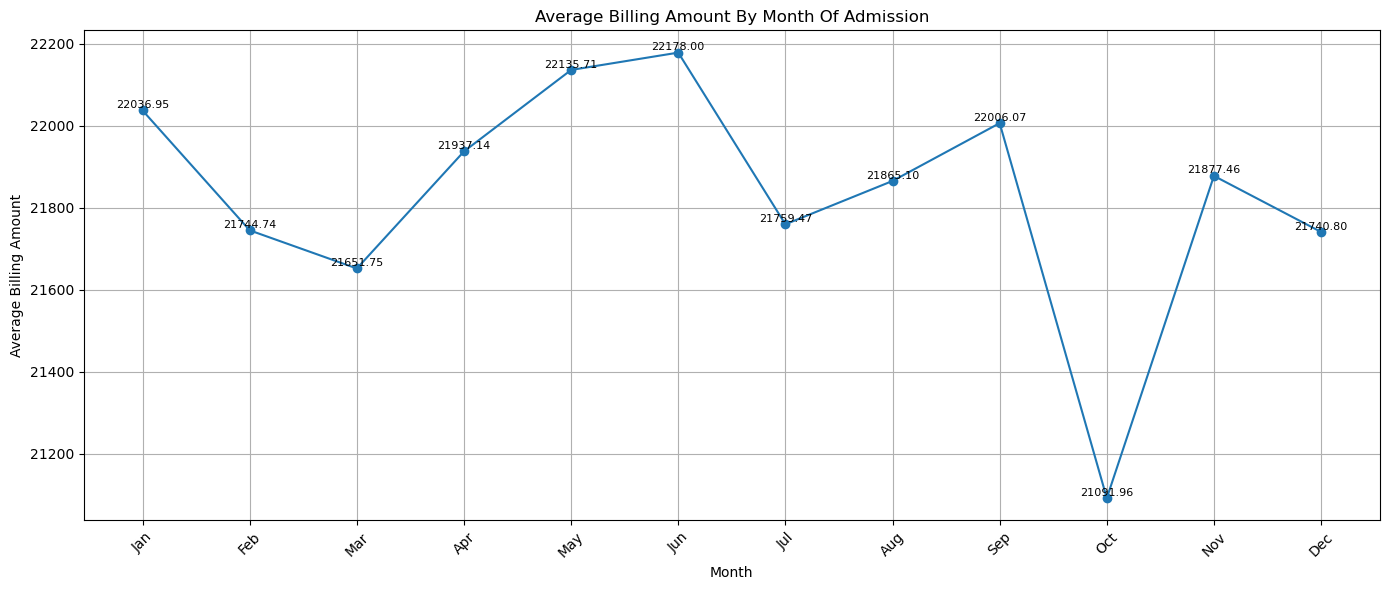

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Declaration
# Exploratory Data Analysis (EDA) - Line Chart Average Billing Amount By Month Of Admission
data = pd.read_csv("modified_healthcare_dataset.csv")

# Get Month
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], errors='coerce')
data['Month'] = data['Date of Admission'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data['MonthName'] = data['Month'].apply(lambda x: month_names[x - 1])

# Group by Month and avg Billing Amount
data['Billing Amount'] = pd.to_numeric(data['Billing Amount'], errors='coerce')
monthly_billing = data.groupby('MonthName')['Billing Amount'].mean().reindex(month_names, fill_value=0)

# Plot line chart
plt.figure(figsize=(14, 6))
plt.plot(monthly_billing.index, monthly_billing.values, marker='o')
plt.title('Average Billing Amount By Month Of Admission')
plt.xlabel('Month')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.grid(True)
for x, y in zip(monthly_billing.index, monthly_billing.values):
    plt.text(x, y + 1, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

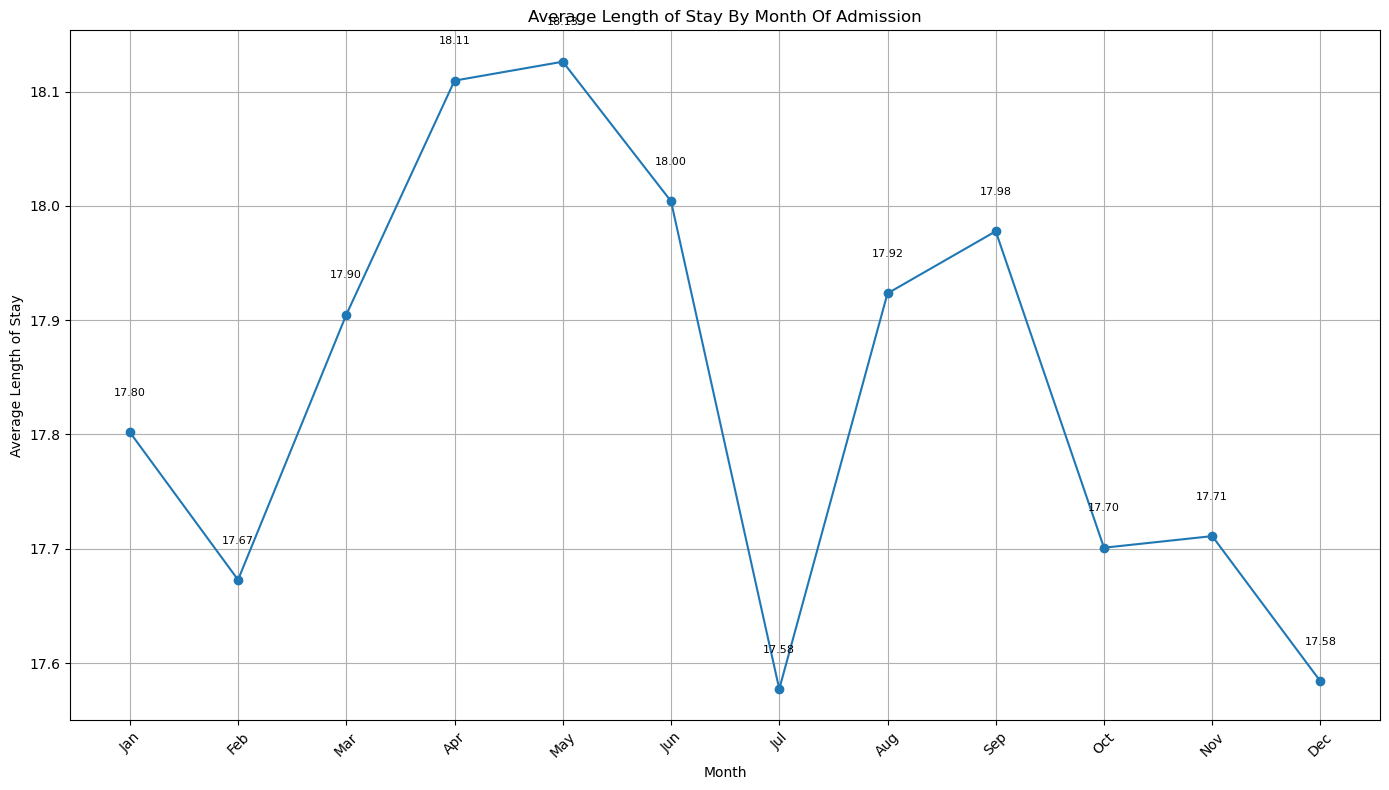

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Declaration
# Exploratory Data Analysis (EDA) - Line Chart Average Length of Stay By Month Of Admission
data = pd.read_csv("modified_healthcare_dataset.csv")

# Get Month
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], errors='coerce')
data['Month'] = data['Date of Admission'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data['MonthName'] = data['Month'].apply(lambda x: month_names[x - 1])

# Group by Month and avg Length of Stay
data['Length of Stay'] = pd.to_numeric(data['Length of Stay'], errors='coerce')
length_of_stay = data.groupby('MonthName')['Length of Stay'].mean().reindex(month_names, fill_value=0)

# Plot line chart
plt.figure(figsize=(14, 8))
plt.plot(length_of_stay.index, length_of_stay.values, marker='o')
plt.title('Average Length of Stay By Month Of Admission')
plt.xlabel('Month')
plt.ylabel('Average Length of Stay')
plt.xticks(rotation=45)
plt.grid(True)
for x, y in zip(monthly_billing.index, monthly_billing.values):
    plt.text(x, y + 0.03, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

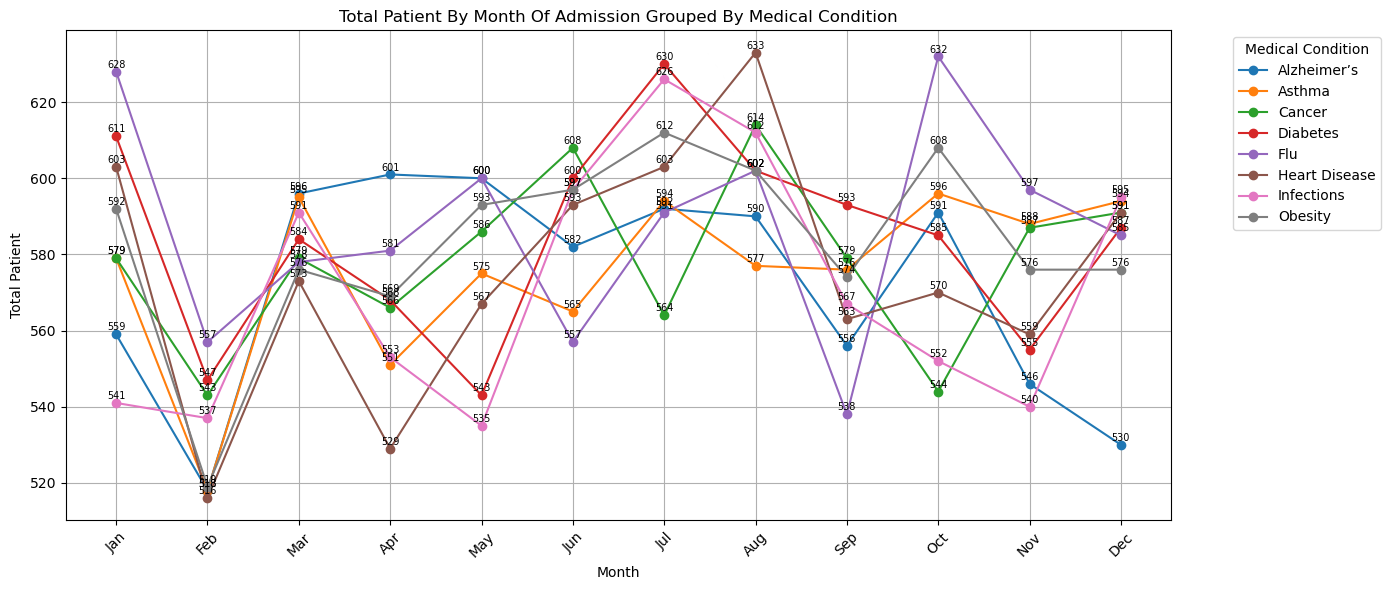

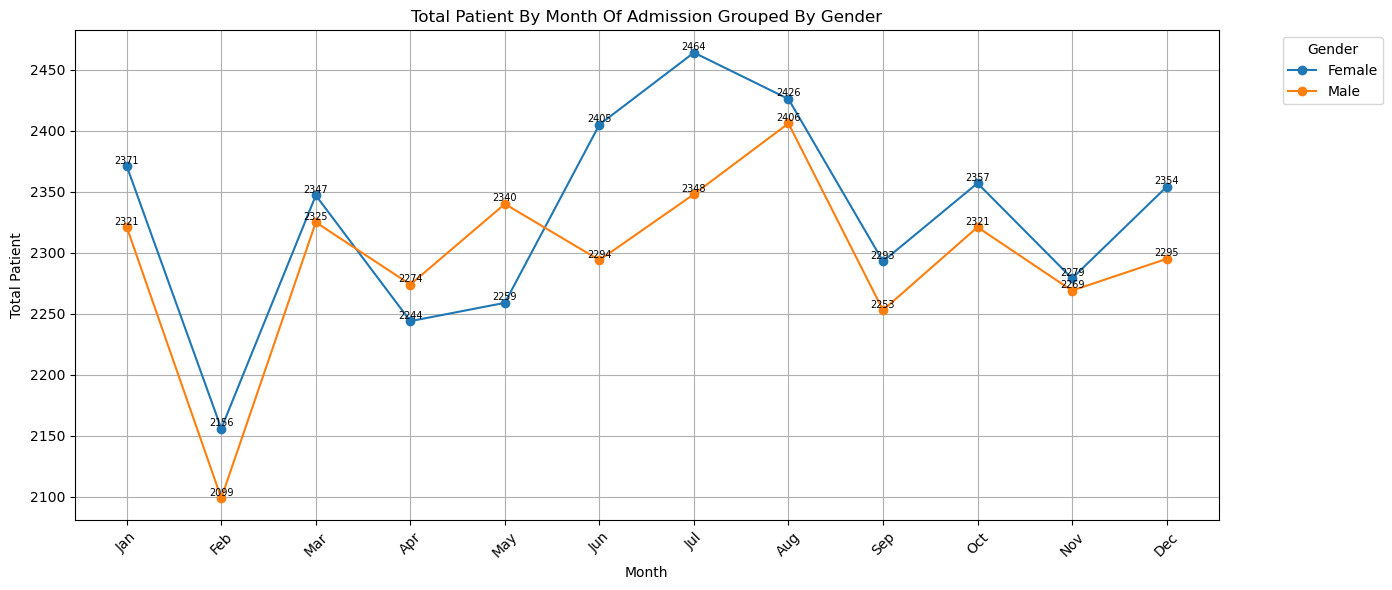

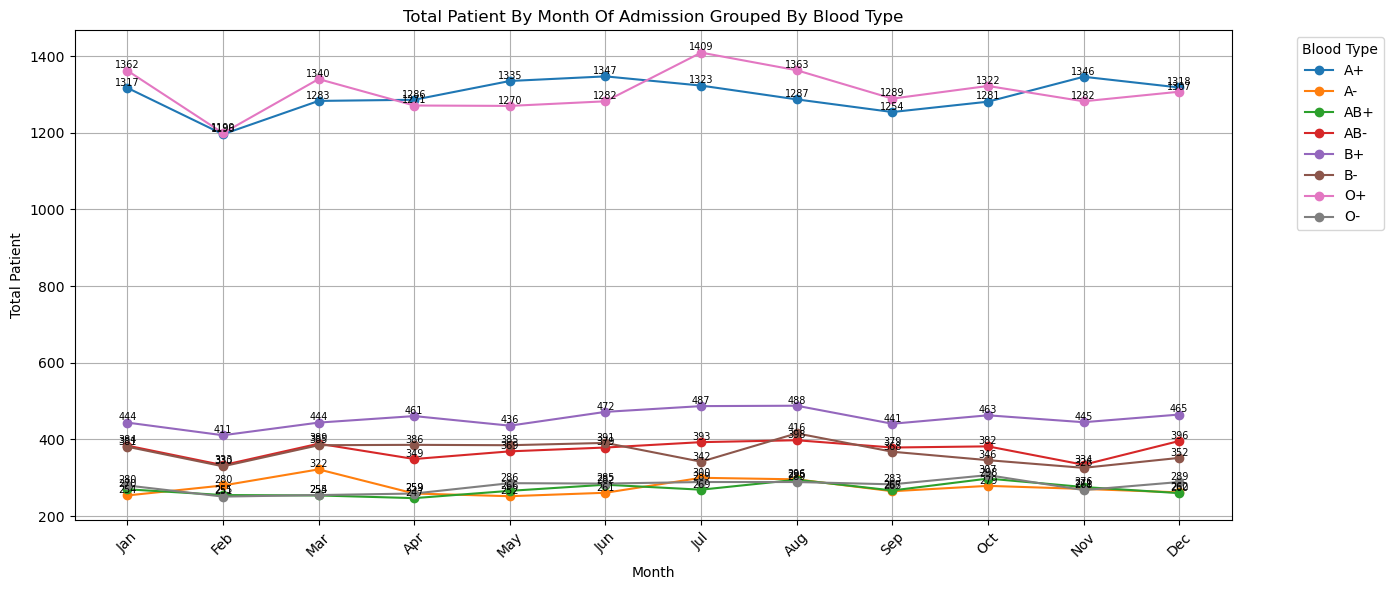

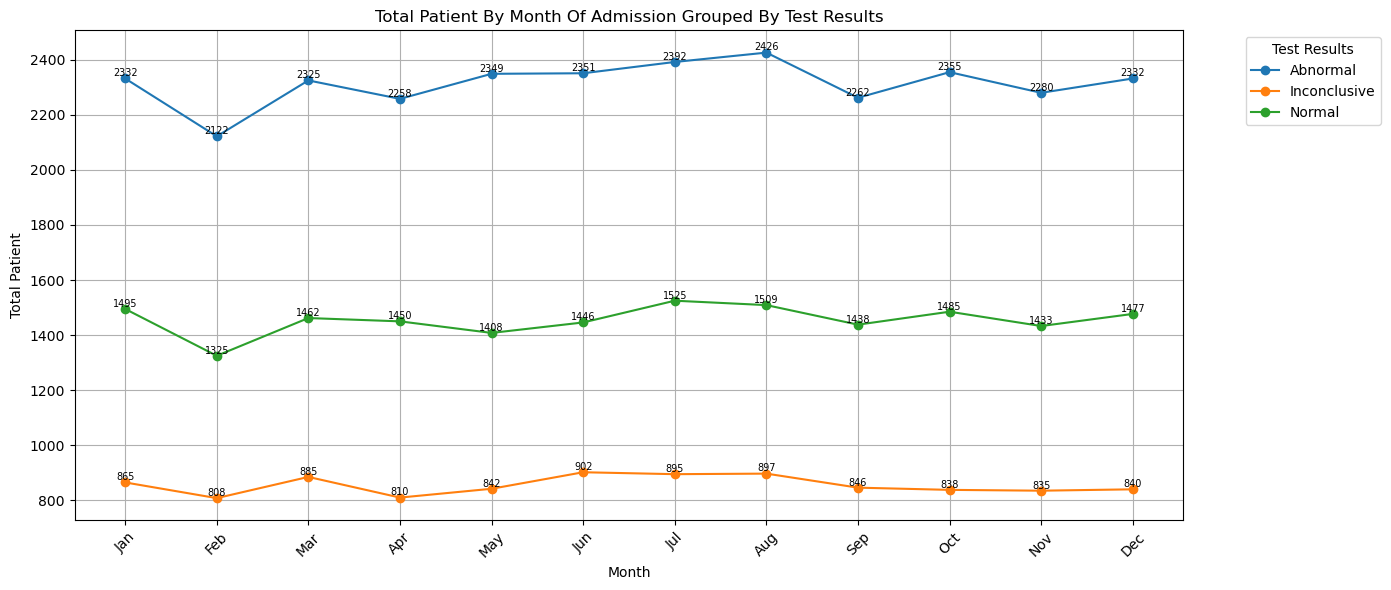

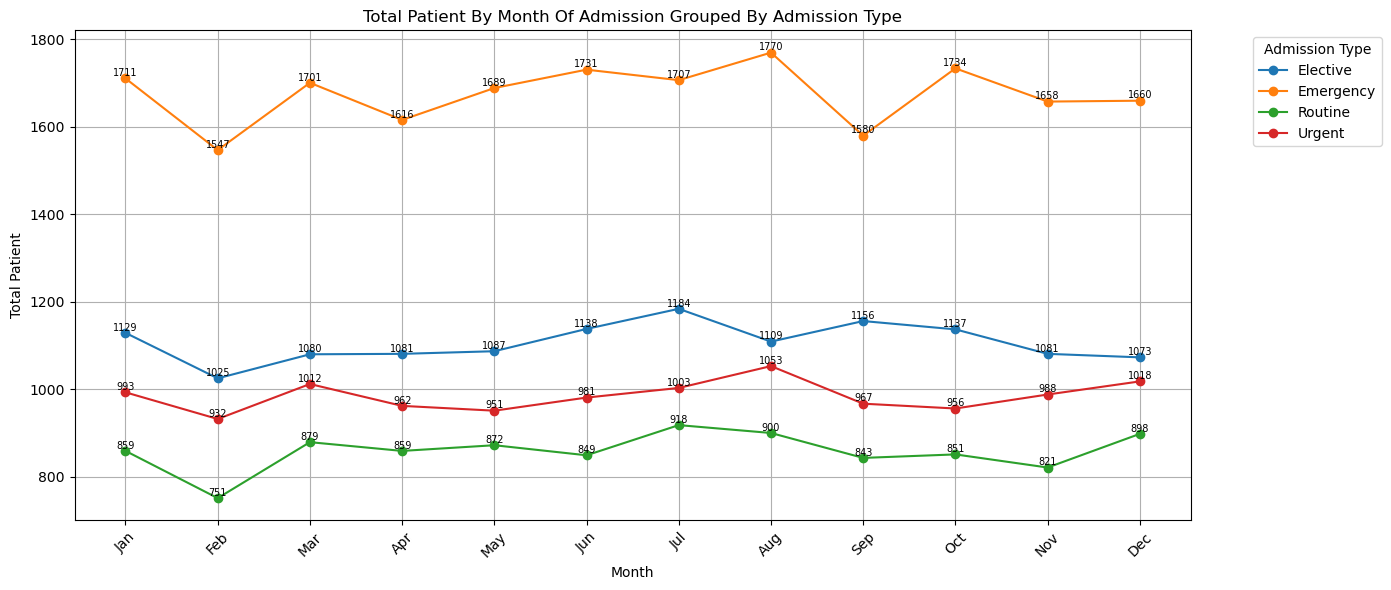

In [11]:
import pandas as pd
import statistics
import numpy as np
import matplotlib.pyplot as plt
import squarify

# Declaration
# Exploratory Data Analysis (EDA) - Line Chart Total Patient By Month Of Admission Grouped By Context
data = pd.read_csv("modified_healthcare_dataset.csv")

target_col = ['Medical Condition','Gender','Blood Type','Test Results','Admission Type']

for dt in target_col:
    # Get Month
    data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], errors='coerce')
    data['Month'] = data['Date of Admission'].dt.month
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    data['MonthName'] = data['Month'].apply(lambda x: month_names[x - 1] if not pd.isna(x) else None)
    
    # Group by MonthName and Context
    grouped = data.groupby(['MonthName', dt]).size().reset_index(name='Total')
    pivot = grouped.pivot(index='MonthName', columns=dt, values='Total').reindex(month_names).fillna(0)
    
    # Plot Line Chart
    plt.figure(figsize=(14, 6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker='o', label=col)
    
    plt.title(f'Total Patient By Month Of Admission Grouped By {dt}')
    plt.xlabel('Month')
    plt.ylabel('Total Patient')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title=dt, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add Labels
    for col in pivot.columns:
        for x, y in zip(pivot.index, pivot[col]):
            if y > 0:
                plt.text(x, y + 0.5, str(int(y)), ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.show()